In [19]:
pip install selenium webdriver-manager

Note: you may need to restart the kernel to use updated packages.


In [20]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
import json
import pandas as pd
import matplotlib.pyplot as plt

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument("--start-maximized")
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
driver.get("https://socialblade.com/tiktok/user/xxl.scrunchie")

html = driver.page_source
driver.quit()

# Extract the NEXT_DATA JSON
start = html.find("__NEXT_DATA__")
json_start = html.find("{", start)
json_end = html.find("</script>", json_start)
json_str = html[json_start:json_end]
data = json.loads(json_str)

queries = []
if "trpcState" in data:
    queries = data["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"] and "trpcState" in data["props"]["pageProps"]:
    queries = data["props"]["pageProps"]["trpcState"]["json"]["queries"]
elif "props" in data and "pageProps" in data["props"]:
    # fallback scan entire object for queries
    for v in data["props"]["pageProps"].values():
        if isinstance(v, dict) and "queries" in v:
            queries = v["queries"]

history_block = None
for q in queries:
    if q["queryKey"][0] == ["tiktok", "history"]:
        history_block = q
        break

if history_block is None:
    raise Exception("Could not find the TikTok history block.")

# Extract the daily stats
days = history_block["state"]["data"]

# Build DataFrame
df = pd.DataFrame(days)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [21]:
try:
    df.head()
    print("df is loaded.")
except:
    print("df DOES NOT exist. You need to run the scraping cell again.")



df is loaded.


In [22]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df["new_followers"] = df["followers"].diff()

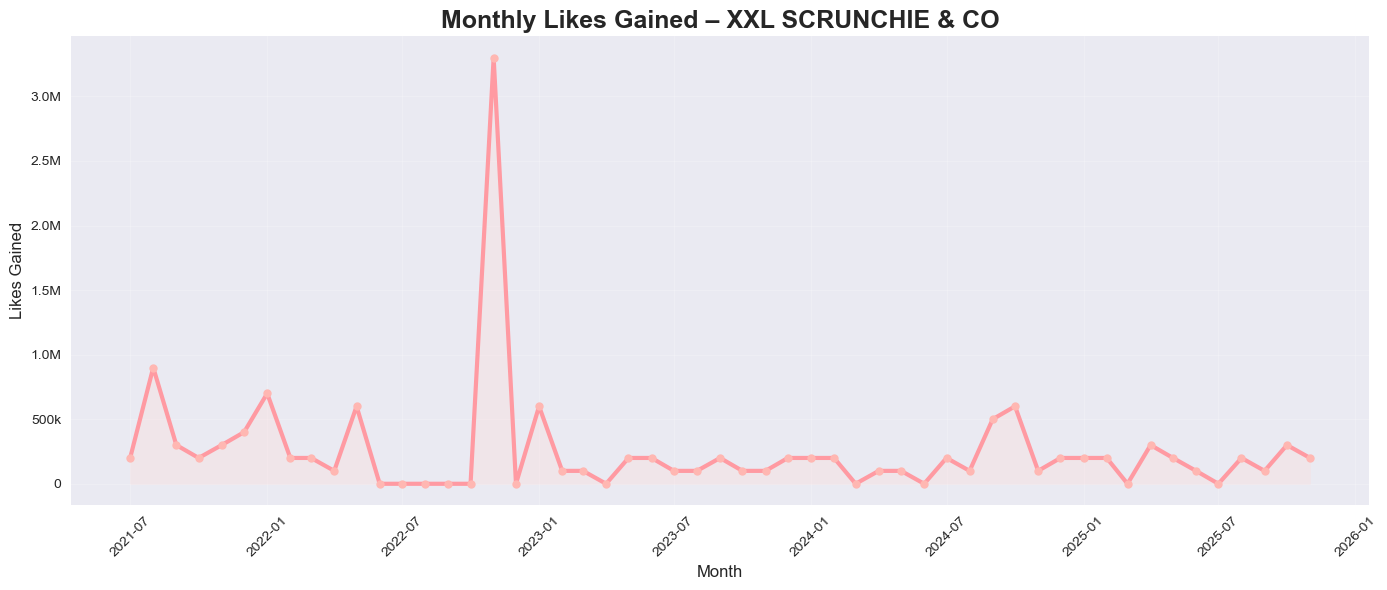

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Monthly gained likes data
likes_data = {
    "Jul 2021": 200_000,
    "Aug 2021": 900_000,
    "Sep 2021": 300_000,
    "Oct 2021": 200_000,
    "Nov 2021": 300_000,
    "Dec 2021": 400_000,

    "Jan 2022": 700_000,
    "Feb 2022": 200_000,
    "Mar 2022": 200_000,
    "Apr 2022": 100_000,
    "May 2022": 600_000,
    "Jun 2022": 0,
    "Jul 2022": 0,
    "Aug 2022": 0,
    "Sep 2022": 0,
    "Oct 2022": 0,
    "Nov 2022": 3_300_000,
    "Dec 2022": 0,

    "Jan 2023": 600_000,
    "Feb 2023": 100_000,
    "Mar 2023": 100_000,
    "Apr 2023": 0,
    "May 2023": 200_000,
    "Jun 2023": 200_000,
    "Jul 2023": 100_000,
    "Aug 2023": 100_000,
    "Sep 2023": 200_000,
    "Oct 2023": 100_000,
    "Nov 2023": 100_000,
    "Dec 2023": 200_000,

    "Jan 2024": 200_000,
    "Feb 2024": 200_000,
    "Mar 2024": 0,
    "Apr 2024": 100_000,
    "May 2024": 100_000,
    "Jun 2024": 0,
    "Jul 2024": 200_000,
    "Aug 2024": 100_000,
    "Sep 2024": 500_000,
    "Oct 2024": 600_000,
    "Nov 2024": 100_000,
    "Dec 2024": 200_000,

    "Jan 2025": 200_000,
    "Feb 2025": 200_000,
    "Mar 2025": 0,
    "Apr 2025": 300_000,
    "May 2025": 200_000,
    "Jun 2025": 100_000,
    "Jul 2025": 0,
    "Aug 2025": 200_000,
    "Sep 2025": 100_000,
    "Oct 2025": 300_000,
    "Nov 2025": 200_000,
}

# Build a continuous monthly time series 
date_index = pd.date_range("2021-07-01", "2025-11-01", freq="MS")

likes_df = pd.DataFrame({
    "month": date_index,
    "likes": [likes_data.get(d.strftime("%b %Y"), 0) for d in date_index]
})

# Formatter for y-axis 
def like_formatter(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{int(x/1_000)}k"
    else:
        return str(int(x))

# Line chart
plt.figure(figsize=(14, 6))

plt.plot(
    likes_df["month"], likes_df["likes"],
    color="#ff9aa2", linewidth=3, marker="o", markersize=6,
    markerfacecolor="#ffb7b2", markeredgecolor="#ff9aa2"
)

plt.fill_between(likes_df["month"], likes_df["likes"],
                 color="#ffdad7", alpha=0.3)

plt.title("Monthly Likes Gained – XXL SCRUNCHIE & CO",
          fontsize=18, fontweight="bold")

plt.xlabel("Month", fontsize=12)
plt.ylabel("Likes Gained", fontsize=12)

plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(like_formatter))

plt.tight_layout()
plt.savefig("xxl_pastel_line_chart.png", dpi=300)
plt.show()





This data of monthly gained likes for XXL Scrunchie & Co shows how a small business can earn a lot visibility when their content goes viral. The account's massive spike in likes during November 2022 (over 3.3 million likes in one month) demonstrates the kind of sudden exposure that TikTok can give to small brands, rapidly driving huge interest and sales. Even though monthly likes fluctuate afterward, the consistent engagement across 2023–2025 shows how social media can sustain growth long after the initial viral moment. This pattern illustrates the broader small-business boom on platforms like TikTok, where one strong wave of attention can launch a long-term brand presence.